In [ ]:
# Week 1 Day 7 - Wine KNN Mini project

## Goal

Build a complete KNN classification workflow using the Wine dataset.

## Pipeline

1. Load dataset
2. Split data into train, validation, and test sets
3. Apply feature scaling correctly
4. Tune k using validation set
5. Evaluate final model on test set.
6. Analyze results

In [2]:
from sklearn.datasets import load_wine

wine = load_wine()

X = wine.data
y = wine.target

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Feature names:", wine.feature_names)
print("Class names:", wine.target_names)

X shape: (178, 13)
y shape: (178,)
Feature names: ['alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium', 'total_phenols', 'flavanoids', 'nonflavanoid_phenols', 'proanthocyanins', 'color_intensity', 'hue', 'od280/od315_of_diluted_wines', 'proline']
Class names: ['class_0' 'class_1' 'class_2']


In [3]:
from sklearn.model_selection import train_test_split

# First split: 60% train, 40% temporary
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.4,
    random_state=42,
    stratify=y
)

# Second split: 20% validation, 20% test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.5,
    random_state=42,
    stratify=y_temp
)

print("Train:", X_train.shape, y_train.shape)
print("Validation:", X_val.shape, y_val.shape)
print("Test:", X_test.shape, y_test.shape) 

Train: (106, 13) (106,)
Validation: (36, 13) (36,)
Test: (36, 13) (36,)


In [5]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Important: fit only on training data
scaler.fit(X_train)

X_train_scaled = scaler.transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print("Scaled train shape:", X_train_scaled.shape)
print("Scaled validation shape:", X_val_scaled.shape)
print("Scaled test shape:", X_test_scaled.shape)

Scaled train shape: (106, 13)
Scaled validation shape: (36, 13)
Scaled test shape: (36, 13)


In [6]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

k_values = range(1,16)
val_accuracies = []

for k in k_values:
    model = KNeighborsClassifier(n_neighbors=k)

    model.fit(X_train_scaled, y_train)

    y_val_pred = model.predict(X_val_scaled)

    val_acc = accuracy_score(y_val, y_val_pred)
    val_accuracies.append(val_acc)

    print(f"k={k}, validation accuracy={val_acc:.4f}")

k=1, validation accuracy=0.9167
k=2, validation accuracy=0.8889
k=3, validation accuracy=0.8889
k=4, validation accuracy=0.8889
k=5, validation accuracy=0.9444
k=6, validation accuracy=0.9444
k=7, validation accuracy=0.9444
k=8, validation accuracy=0.9444
k=9, validation accuracy=0.9167
k=10, validation accuracy=0.9722
k=11, validation accuracy=0.9444
k=12, validation accuracy=0.9722
k=13, validation accuracy=0.9722
k=14, validation accuracy=0.9722
k=15, validation accuracy=0.9722


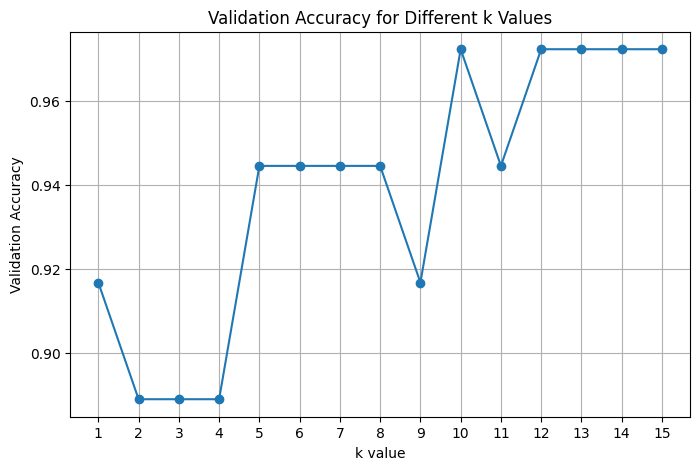

In [7]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(k_values, val_accuracies, marker="o")

plt.xlabel("k value")
plt.ylabel("Validation Accuracy")
plt.title("Validation Accuracy for Different k Values")
plt.xticks(list(k_values))
plt.grid(True)

plt.show()

In [8]:
best_index = val_accuracies.index(max(val_accuracies))
best_k = list(k_values)[best_index]
best_val_acc = val_accuracies[best_index]

print("Best k:", best_k)
print("Best validation accuracy:", best_val_acc)

Best k: 10
Best validation accuracy: 0.9722222222222222


In [10]:
final_model = KNeighborsClassifier(n_neighbors=best_k)

final_model.fit(X_train_scaled, y_train)

y_test_pred = final_model.predict(X_test_scaled)

test_acc = accuracy_score(y_test, y_test_pred)

print("Final Test Accuracy:", test_acc)

Final Test Accuracy: 0.9444444444444444


In [11]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        y_test_pred,
        target_names=wine.target_names
    )
)

              precision    recall  f1-score   support

     class_0       0.92      1.00      0.96        12
     class_1       1.00      0.87      0.93        15
     class_2       0.90      1.00      0.95         9

    accuracy                           0.94        36
   macro avg       0.94      0.96      0.95        36
weighted avg       0.95      0.94      0.94        36



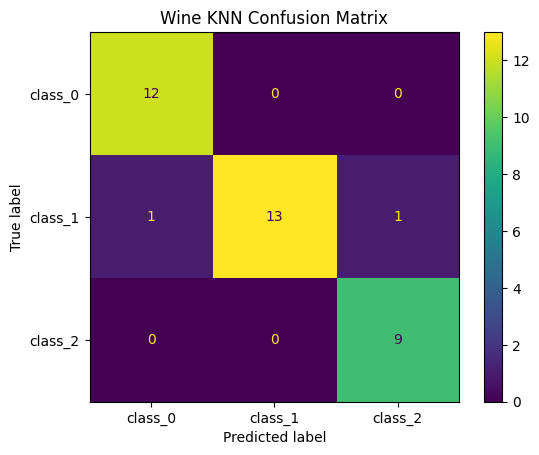

In [13]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_test_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=wine.target_names
)

disp.plot()
plt.title("Wine KNN Confusion Matrix")
plt.show()

In [ ]:
# Reflection

## 1. Why did we split the data into Train, Validation and Test sets?
Ensuring the isolated test datasets and preventing data leakage in the satge of test. Validation is the process of tuning parameters in 
models.
    
## 2. Why did we apply StandardScaler?
Making the different mean and std of feature values approximately equal to 0 and 1 respectively, contributing to comprehensively refer to 
each features.

## 3. Why was k=10 selected?
When k=10, there is the best accuracy. Even if k=12,13,14,15 has the same accuracy, the modle already learnt some features to the extent.

## 4. What did I learn from this mini project?
I learnt the whole steps of pipeline and reveiwed all knowlege in this week.